<a href="https://colab.research.google.com/github/ishagt/ML_labs/blob/main/dbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:68: SyntaxWarning: invalid escape sequence '\e'
<>:68: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1296/2007140539.py:68: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f"DBSCAN Result ($\epsilon={eps}$, MinPts={min_samples})", fontsize=14)


  Point  X  Y  Cluster Point Type
0    P1  1  2        0       Core
1    P2  2  1        0     Border
2    P3  2  3        0       Core
3    P4  3  4        0       Core
4    P5  4  4        0     Border


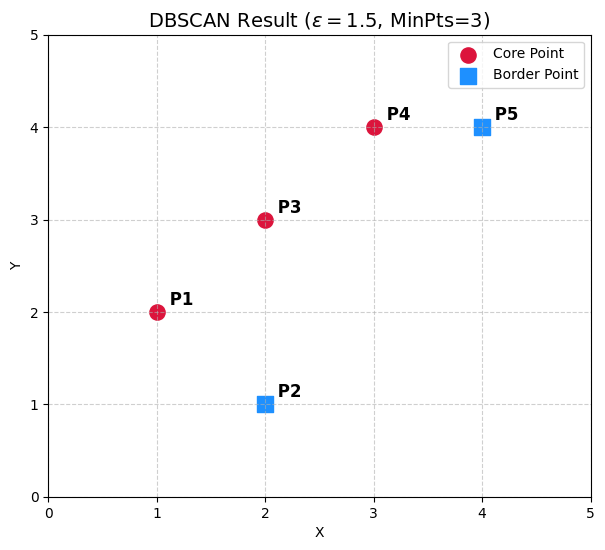

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1. Dataset from Excel mockup
data = {
    'Point': ['P1', 'P2', 'P3', 'P4', 'P5'],
    'X': [1, 2, 2, 3, 4],
    'Y': [2, 1, 3, 4, 4]
}
df = pd.DataFrame(data)
X = df[['X', 'Y']].values

# 2. Parameters from Excel sheet
eps = 1.5
min_samples = 3

# 3. Fit DBSCAN model
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
df['Cluster'] = dbscan.fit_predict(X)

# Identify Core, Border, and Noise points
core_indices = set(dbscan.core_sample_indices_)
point_types = []
for idx in range(len(df)):
    if idx in core_indices:
        point_types.append('Core')
    elif df.loc[idx, 'Cluster'] != -1:
        point_types.append('Border')
    else:
        point_types.append('Noise')

df['Point Type'] = point_types

# Display the classification results
print(df)

# 4. Plot the points with annotations
plt.figure(figsize=(7, 6))

colors = {'Core': 'crimson', 'Border': 'dodgerblue', 'Noise': 'black'}
markers = {'Core': 'o', 'Border': 's', 'Noise': 'x'}

for p_type in ['Core', 'Border', 'Noise']:
    subset = df[df['Point Type'] == p_type]
    if not subset.empty:
        plt.scatter(
            subset['X'],
            subset['Y'],
            c=colors[p_type],
            marker=markers[p_type],
            s=120,
            label=f'{p_type} Point'
        )

# Add point names (P1 - P5) to the plot
for _, row in df.iterrows():
    plt.annotate(
        f" {row['Point']}",
        (row['X'], row['Y']),
        fontsize=12,
        fontweight='bold',
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title(f"DBSCAN Result ($\epsilon={eps}$, MinPts={min_samples})", fontsize=14)
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()